In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection
import scipy.sparse.linalg as sla
import scipy.sparse as sp
from ssh_chain import PHOTONICChain

In [5]:
def make_edge_lifting_perturbation(chain, strength=1e-6):
    """
    Diagonal perturbation: delta_i = strength * (exp(-i/xi) - exp(-(2N-1-i)/xi))
    Positive on left edge sites, negative on right edge sites.
    This lifts the degeneracy without mixing the states significantly.
    """
    n     = 2 * chain.N
    xi    = n / 4.0   # decay length ~ quarter chain
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # weight per site: +exp on left, -exp on right
    site_weights = np.array([np.exp(-i / xi) - np.exp(-(n - 1 - i) / xi)
                             for i in range(n)])

    # build diagonal in matter Fock basis
    diag_mat = np.zeros(d_mat)
    for exc, arr in chain.fock_states.items():
        offset = chain.fock_offsets[exc]
        for s_idx, state in enumerate(arr):
            diag_mat[offset + s_idx] = sum(
                ni * site_weights[i] for i, ni in enumerate(state))

    # tensor with photon identity
    full_diag = strength * np.tile(diag_mat, d_ph)
    return sp.diags(full_diag, format='csr')

gap_threshold = 1e-4

def resolve_edge_states(chain, scale):
    H_pert = scale * (chain.H + make_edge_lifting_perturbation(chain, strength=1e-6))

    results = {}
    for sigma_try in [1.0 + 1e-4, 1.0 - 1e-4, 1.0 + 1e-3, 1.0 - 1e-3]:
        try:
            evals, evecs = sla.eigsh(H_pert, k=6, sigma=scale * sigma_try, which='LM')
            for i, e in enumerate(evals):
                if not any(abs(e - e2) < 1e-9 for e2 in results):
                    results[e] = evecs[:, i]
            if len(results) >= 4:
                break
        except RuntimeError:
            continue

    all_energies_scaled   = np.array(sorted(results.keys()))
    all_energies_physical = all_energies_scaled / scale
    all_states            = np.column_stack([results[e] for e in all_energies_scaled])

    near_mask = np.abs(all_energies_physical - 1.0) < gap_threshold
    if near_mask.sum() < 2:
        near_mask = np.zeros(len(all_energies_physical), dtype=bool)
        near_mask[np.argsort(np.abs(all_energies_physical - 1.0))[:2]] = True

    V_near = all_states[:, near_mask]
    E_near = all_energies_physical[near_mask]

    if V_near.shape[1] > 2:
        best2  = np.argsort(np.abs(E_near - 1.0))[:2]
        V_near = V_near[:, best2]
        E_near = E_near[best2]

    e_order  = np.argsort(E_near)
    V_sorted = V_near[:, e_order]

    return V_sorted[:, 0], V_sorted[:, 1]

def old_basis_matter_vec(evec, chain):
    d_ph  = chain.fock_photon
    d_mat = chain.fock_dim

    # 1. partial trace -> leading matter eigenvector (Bogoliubov basis)
    rho_matter     = chain.partial_trace(evec, which_to_keep='matter')
    _, evecs_rho   = np.linalg.eigh(rho_matter)
    matter_vec_new = evecs_rho[:, -1]

    # 2. embed as a photon-0 state in the full tensor-product space
    synth_vec         = np.zeros(d_ph * d_mat, dtype=complex)
    synth_vec[:d_mat] = matter_vec_new

    # 3. call the class method directly
    old_decomp = chain.decompose_to_old_fock(synth_vec)
    old_sector = old_decomp.get(0, {})

    # 4. reconstruct old-basis vector
    old_vec = np.zeros(d_mat, dtype=complex)
    for state_tuple, coeff in old_sector.items():
        exc = sum(state_tuple)
        if (exc in chain.fock_state_index
                and state_tuple in chain.fock_state_index[exc]):
            s_idx = chain.fock_state_index[exc][state_tuple]
            old_vec[chain.fock_offsets[exc] + s_idx] += coeff

    return old_vec


In [ ]:
# ------------------------------------------------------------------ #
# Parameters
# ------------------------------------------------------------------ #
N = 10
gamma_zero = 0.03
fock_photon = 4
Omega_J = 1.0
Chi_J = 0.0
base_excitations = 1
fock_layers = 0
k_states = (4 * N - 1)
Omega_C_values = [0.2, 0.3]
Chi_C_values   = np.linspace(-0.75, 0.75, 20)

In [13]:
# ------------------------------------------------------------------ #
# Compute spectra + matter purity
# ------------------------------------------------------------------ #
all_energies  = []
all_purities  = []

for Omega_C in Omega_C_values:
    energies_list = []
    purities_list = []

    for Chi_C in Chi_C_values:
        print(Chi_C)
        aux     = 0.5 * Omega_C
        gamma   = gamma_zero * Omega_C / np.max(Omega_C_values)
        omega_r = 1.03 * np.sqrt(1 + aux) - np.sqrt(1 - aux)
        scale   = np.exp(10 * np.abs(Chi_C))

        chain = PHOTONICChain(N, Omega_C, Chi_C, omega_r, gamma, fock_photon,
                              Omega_J, Chi_J, False)
        chain.matter_hamiltonians(n_excitations=base_excitations, layers=fock_layers)
        chain.build_full_hamiltonian()

        vals, vecs = chain.get_low_lying_spectrum(k=k_states)
        idx_sort   = np.argsort(vals)
        vals       = vals[idx_sort]
        vecs       = vecs[:, idx_sort]

        try:
            evec_left, evec_right = resolve_edge_states(chain, scale)
            vecs[:, N - 1] = evec_left
            vecs[:, N]     = evec_right
        except Exception:
            pass

        chain.build_squeezed_vacuum(truncation=1)

        # ── cache new->old translations ──────────────────────────────
        chain._new_to_old_cache = {}
        for col in range(vecs.shape[1]):
            decomp = chain.decompose_tensor_state(vecs[:, col])
            for alpha, matter_dict in decomp.items():
                for new_state_tuple in matter_dict:
                    if new_state_tuple not in chain._new_to_old_cache:
                        chain._new_to_old_cache[new_state_tuple] = chain.new_to_old_fock(
                            np.array(new_state_tuple, dtype=int))

        # ── collect all old-basis states ─────────────────────────────
        all_old_states = set()
        for old_dict in chain._new_to_old_cache.values():
            all_old_states.update(old_dict.keys())

        sorted_states     = sorted(all_old_states, key=lambda s: (sum(s), s))
        state_to_idx      = {s: i for i, s in enumerate(sorted_states)}
        d_mat_old         = len(sorted_states)

        d_ph  = chain.fock_photon
        d_mat = chain.fock_dim
        n     = 2 * chain.N

        # ── change-of-basis matrix C: (d_mat_old, d_mat_new) ────────
        C = np.zeros((d_mat_old, d_mat), dtype=complex)
        for new_state_tuple, old_dict in chain._new_to_old_cache.items():
            exc = sum(new_state_tuple)
            if exc not in chain.fock_state_index:
                continue
            if new_state_tuple not in chain.fock_state_index[exc]:
                continue
            s_idx = chain.fock_state_index[exc][new_state_tuple]
            col_c = chain.fock_offsets[exc] + s_idx
            norm  = np.sqrt(sum(abs(v)**2 for v in old_dict.values()))
            for old_state, coeff in old_dict.items():
                C[state_to_idx[old_state], col_c] += coeff / (norm if norm > 1e-15 else 1.0)

        # ── project all eigenvectors ─────────────────────────────────
        # vecs:   (d_ph * d_mat, k_states)
        # amp_3d: (d_ph, d_mat_old, k_states)
        vecs_3d = vecs.reshape(d_ph, d_mat, k_states)
        amp_3d  = np.tensordot(C, vecs_3d, axes=([1], [1]))   # (d_mat_old, d_ph, k_states)
        amp_3d  = amp_3d.transpose(1, 0, 2)                   # (d_ph, d_mat_old, k_states)

        # ── matter purity for all states at once ─────────────────────
        # rho_matter[:, :, k] = amp_3d[:, :, k].conj().T @ amp_3d[:, :, k]
        # shape of amp_3d:  (d_ph, d_mat_old, k_states)
        # we want Tr(rho^2) = ||rho_matter||_F^2 for each state k
        #
        # rho_matter[m, m', k] = Σ_alpha amp_3d[alpha, m, k]* amp_3d[alpha, m', k]
        # Tr(rho^2)[k] = Σ_{m,m'} |rho[m,m',k]|^2
        #              = Σ_{m,m'} |Σ_alpha amp*[alpha,m,k] amp[alpha,m',k]|^2
        #
        # Efficient: for each k, rho_k = amp_3d[:,:,k].conj().T @ amp_3d[:,:,k]
        # then purity = ||rho_k||_F^2 = np.sum(np.abs(rho_k)**2)
        #
        # Vectorized over k:
        # amp: (d_ph, d_mat_old, k_states) -> reshape to (d_ph, d_mat_old * k_states)
        # then batch the matmul

        purities_this = np.zeros(k_states)
        for k in range(k_states):
            # amp_k: (d_ph, d_mat_old)
            amp_k   = amp_3d[:, :, k]
            # rho_k = amp_k^dag @ amp_k: (d_mat_old, d_mat_old)
            rho_k   = amp_k @ amp_k.conj().T
            purities_this[k] = np.real(np.sum(np.abs(rho_k)**2))

        energies_list.append(vals)
        purities_list.append(purities_this)

    all_energies.append(np.array(energies_list))
    all_purities.append(np.array(purities_list))



-0.75
-0.6710526315789473
-0.5921052631578947
-0.5131578947368421
-0.4342105263157895
-0.35526315789473684
-0.27631578947368424
-0.19736842105263164
-0.11842105263157898
-0.03947368421052633
0.03947368421052633
0.11842105263157887
0.19736842105263153
0.27631578947368407
0.3552631578947367
0.4342105263157894
0.513157894736842
0.5921052631578947
0.6710526315789473
0.75
-0.75
-0.6710526315789473
-0.5921052631578947
-0.5131578947368421
-0.4342105263157895
-0.35526315789473684
-0.27631578947368424
-0.19736842105263164
-0.11842105263157898
-0.03947368421052633
0.03947368421052633
0.11842105263157887
0.19736842105263153
0.27631578947368407
0.3552631578947367
0.4342105263157894
0.513157894736842
0.5921052631578947
0.6710526315789473
0.75


In [16]:
all_purities_copy = 1- np.array(all_purities)

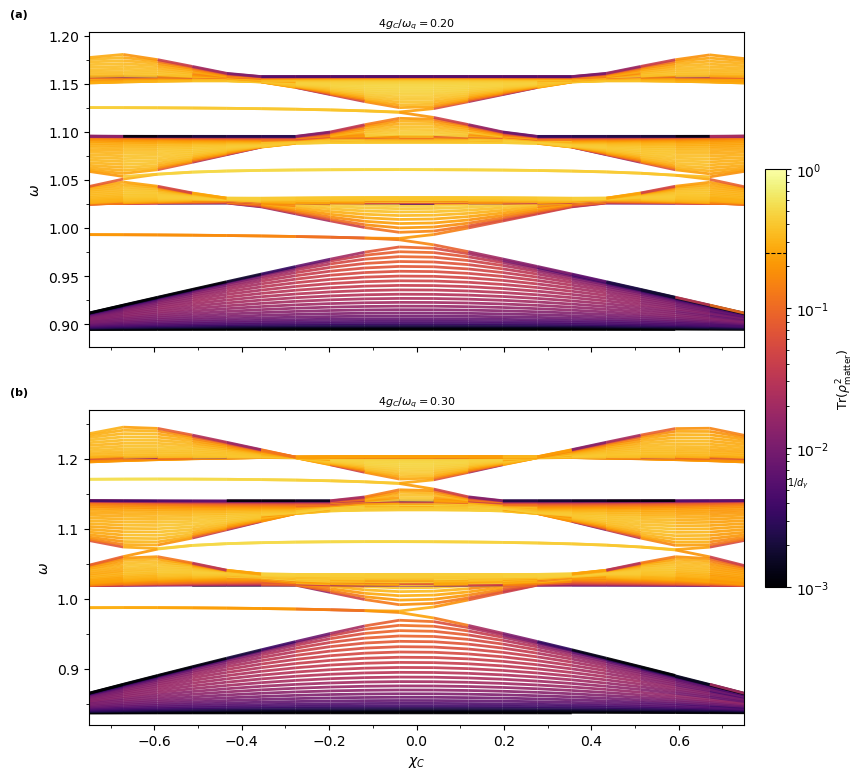

In [ ]:
# ------------------------------------------------------------------ #
# Figure
# ------------------------------------------------------------------ #
nrows, ncols   = len(Omega_C_values), 1
fig_width      = 9.0
fig_height     = 9.0
panel_fontsize = 8

# purity in [0,1]: 1 = pure (product state), 1/d_ph = maximally mixed
# for fock_photon=4: min purity = 0.25
cmap     = plt.cm.inferno
# norm_pur =  mcolors.PowerNorm(gamma=1.0, vmin=0.0, vmax=1.0)
norm_pur = mcolors.LogNorm(vmin=1e-3, vmax=1.0)
fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(fig_width, fig_height))
if nrows == 1:
    axes = [axes]

for idx, (Omega_C, energies, purities) in enumerate(
        zip(Omega_C_values, all_energies, all_purities_copy)):
    ax  = axes[idx]

    for band_e, band_pur in zip(energies.T, purities.T):
        points   = np.array([Chi_C_values, band_e]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        lc = LineCollection(segments, cmap=cmap, norm=norm_pur,
                            linewidth=2.0, alpha=0.9)
        lc.set_array(0.5 * (band_pur[:-1] + band_pur[1:]))
        ax.add_collection(lc)

    ax.set_xlim(Chi_C_values[0], Chi_C_values[-1])
    e_all = energies.flatten()
    ax.set_ylim(e_all.min() - 0.02 * abs(e_all.min()),
                e_all.max() + 0.02 * abs(e_all.max()))

    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))
    ax.text(-0.12, 1.04, f'({chr(97 + idx)})',
            transform=ax.transAxes,
            fontsize=panel_fontsize, fontweight='bold',
            va='bottom', ha='left')
    ax.set_title(rf'$4g_C / \omega_q = {Omega_C:.2f}$', fontsize=8, pad=4)

    if idx == nrows - 1:
        ax.set_xlabel(r'$\chi_C$')
    else:
        ax.tick_params(labelbottom=False)
    ax.set_ylabel(r'$\omega$')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_pur)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical',
                    fraction=0.03, pad=0.03)
cbar.set_label(r'$1-\mathrm{Tr}(\rho_\mathrm{matter}^2)$', fontsize=9)
cbar.ax.axhline(1.0 / fock_photon, color='black', lw=0.8, ls='--')
cbar.ax.text(1.05, 1.0 / fock_photon, r'$1/d_\gamma$',
             transform=cbar.ax.transAxes, fontsize=7, va='center')

# fig.tight_layout(pad=0.4, h_pad=0.5)
plt.show()